In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pip install hampel

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [4]:
P3hobodf = pd.read_csv("P3_current.csv") 
P3hobodf["Date-Time"] = pd.to_datetime(P3hobodf["Date-Time"])
P3date = P3hobodf["Date-Time"]
P3hobodfdate = P3date[1:] 

In [5]:
#filtering the continuous data for the outlier spikes where the hobo probe was removed from the piezometer
P3filteredhobo = hampel(P3hobodf["Temperature"], window_size=6, n_sigma=1.5) 
P3filteredhoboseries = pd.Series(P3filteredhobo.filtered_data, index = P3hobodf.index)
P3filteredhobo = P3filteredhoboseries[1:] 

In [6]:
#reading the manual data
P3mandf = pd.read_csv("P3ManualData.csv", index_col=False)
P3mandf.loc[:,"Temp bottom before"]
P3mandf["Date"] = pd.to_datetime(P3mandf["Date"])


In [7]:
#reading in the NOAA air temp data
weatherdf = pd.read_csv("NOAAHastingsDam2.csv") 
weatherdf["Date"] = pd.to_datetime(weatherdf["Date"])
weather = weatherdf.drop(np.arange(0, 366))

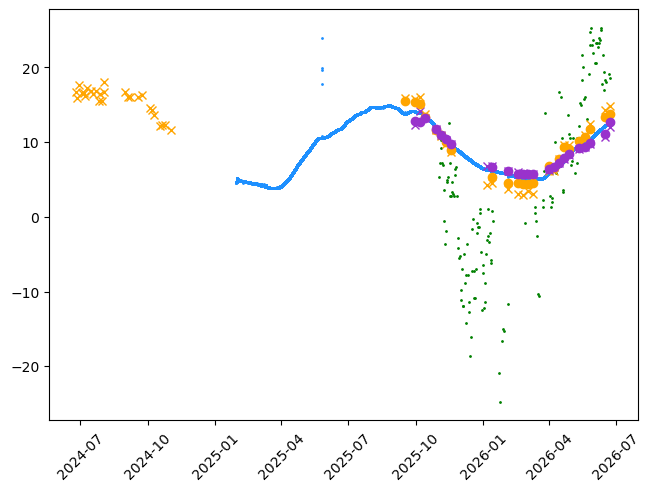

In [8]:
fig, ax = plt.subplots(layout='constrained')
plt.scatter(P3hobodfdate, P3filteredhobo, s = 1, color = "dodgerblue", label = "P3 continuous temperature data")
ax.plot(P3mandf.Date, P3mandf.loc[:,"Temp top before"], 'x', color = "orange", label = "manual temperature at top before pumping") #each variable in the manual field measurmemts data set is called by their column instead of naming each variable. The placeholders here are mandf.Date (which you should replace with the nameofdataframe.nameofcolumnfortime) and mandf.loc[:,"Temp top before"] (which you should replace with nameofdataframe.loc[:, "Name of column for parameter"]). 
ax.plot(P3mandf.Date, P3mandf.loc[:,"Temp bottom before"], 'x', color = "darkorchid", label = "manual temperature at bottom before pumping")
ax.plot(P3mandf.Date, P3mandf.loc[:,"Temp top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
ax.plot(P3mandf.Date, P3mandf.loc[:,"Temp bottom after"], 'o', color = "darkorchid", label = "manual temperature at bottom after pumping")
plt.scatter(weather.Date, weather.loc[:,"Mean  Celcius Teperature"], s = 1, color = "green", label = "air temperature")
plt.xticks(rotation=45)
# plt.ylim((-5, 20))
# plt.xlim((pd.to_datetime("2026-02-18"), pd.to_datetime("2026-02-20")))

# fig.legend(loc='outside upper right')
plt.show;

In [9]:
#P3 SPC

In [10]:
#dropping the 2024-06-25 thru 2024-11-01 data because it seems to have been measured incorrectly.
P3mandf = P3mandf.drop(np.arange(0, 27))
print(P3mandf.loc[:,"SPC top before"])

27    707.0
28    769.0
29    788.0
30    780.0
31    797.0
32    821.0
33    817.0
34    813.0
35    794.0
36    789.0
37    783.0
38    777.0
39    786.0
40    780.0
41    789.0
42    789.0
43    783.0
44    807.0
45    814.0
46    802.0
47    808.0
48    809.0
49    808.0
50    801.0
51    798.0
Name: SPC top before, dtype: float64


In [11]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
P3filteredSPC = hampel(P3hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)

print(P3filteredSPC.filtered_data)

0          9.563297
1        719.073364
2        718.609192
3        718.109863
4        717.481262
            ...    
48948    807.658569
48949    807.820557
48950    807.577576
48951    807.819458
48952    807.749817
Length: 48953, dtype: float32


In [12]:

P3filteredSPCseries = pd.Series(P3filteredSPC.filtered_data, index = P3hobodf.index)

P3filteredSPC = P3filteredSPCseries[1:]              #I used the google AI overview for this line of code :/

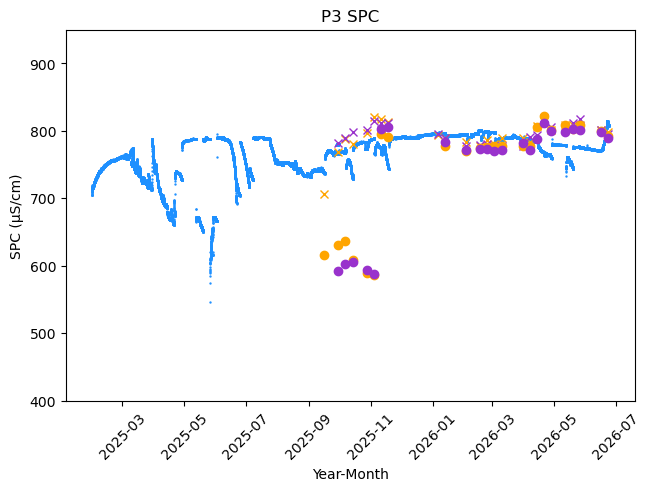

In [16]:
P3hobodate = P3hobodf["Date-Time"]
P3slicedhobodate = P3hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.scatter(P3slicedhobodate, P3filteredSPC, color="dodgerblue", s = 0.5, label = "P3 continuous SPC")
ax.plot(P3mandf.Date, P3mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(P3mandf.Date, P3mandf.loc[:,"SPC bottom before"], 'x', color = "darkorchid", label = "manual SPC at bottom before pumping")
ax.plot(P3mandf.Date, P3mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(P3mandf.Date, P3mandf.loc[:,"SPC bottom after"], 'o', color = "darkorchid", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("P3 SPC")
plt.ylim((400, 950))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
# fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()